<a href="https://colab.research.google.com/github/Anet-Bino/KMeans-Customer-Segmentation/blob/main/KMeans_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Clustering for Customer Segmentation

## Objective
To group mall customers based on Annual Income and Spending Score using K-Means clustering.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv('/content/Mall_Customers.csv')

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.shape

(200, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis

The dataset was explored using histograms, gender distribution and pairplots to understand the customer data.


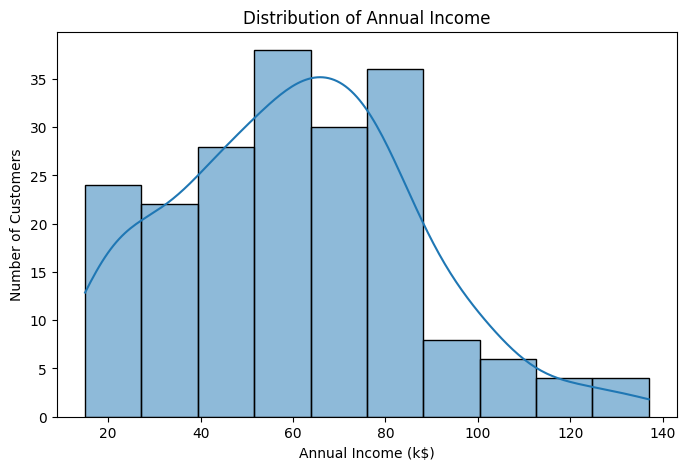

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], kde=True)

plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Number of Customers')

plt.show()

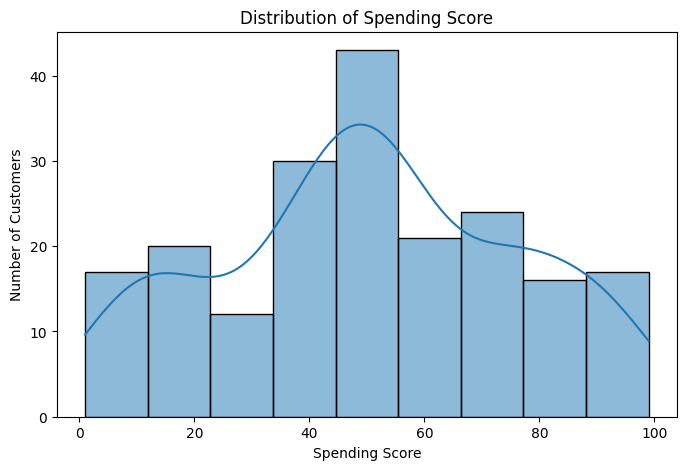

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], kde=True)

plt.title('Distribution of Spending Score')
plt.xlabel('Spending Score')
plt.ylabel('Number of Customers')

plt.show()

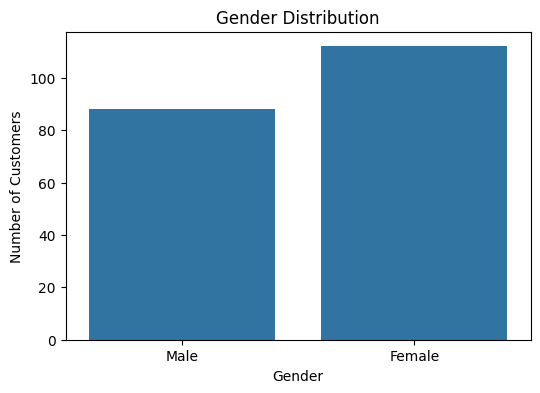

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

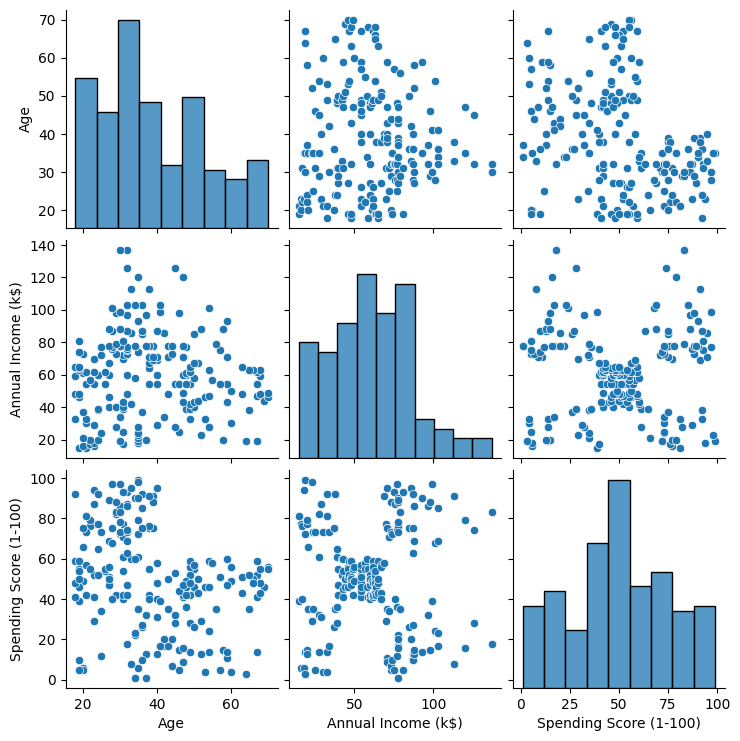

In [ ]:
sns.pairplot(
    df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
)

plt.show()

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

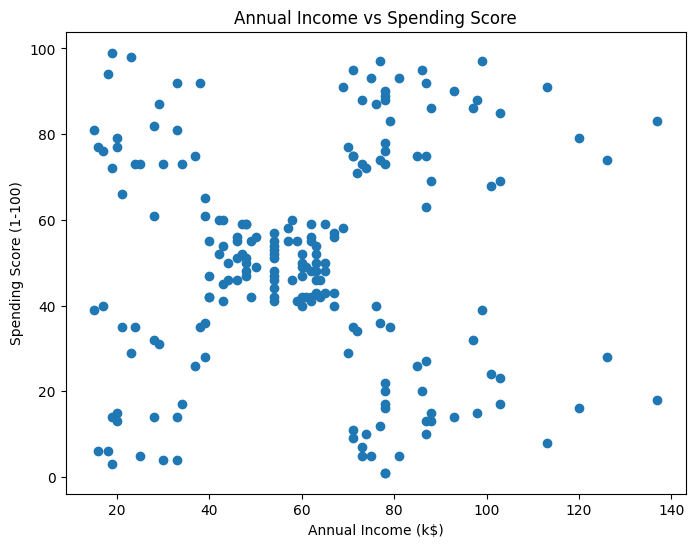

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.show()

## Elbow Method

The Elbow Method was used to find the optimal number of clusters.

The optimal number of clusters was found to be K = 5.

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

print(wcss)

[269981.28000000014, 181363.59595959607, 106348.37306211119, 73679.78903948837, 44448.45544793369, 37233.81451071002, 30241.34361793659, 25036.417604033977, 21916.79478984372, 20072.070939404]


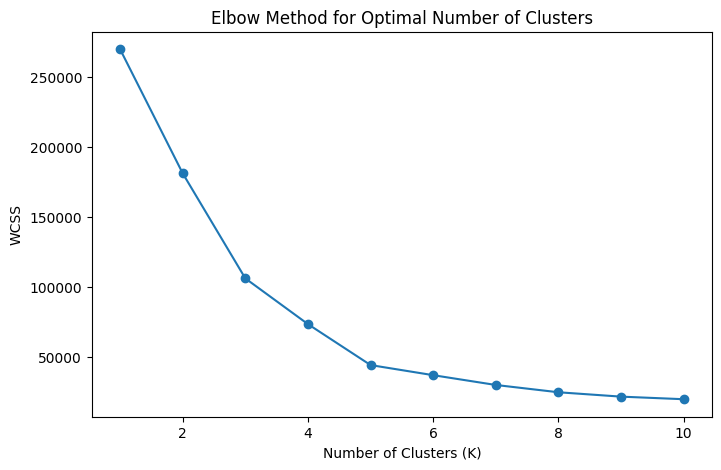

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)

y_kmeans = kmeans.fit_predict(X)

In [ ]:
print(y_kmeans)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [ ]:
df['Cluster'] = y_kmeans

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [ ]:
centroids = kmeans.cluster_centers_

print(centroids)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [ ]:
centroid_df = pd.DataFrame(
    centroids,
    columns=['Annual Income (k$)', 'Spending Score (1-100)']
)

centroid_df

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


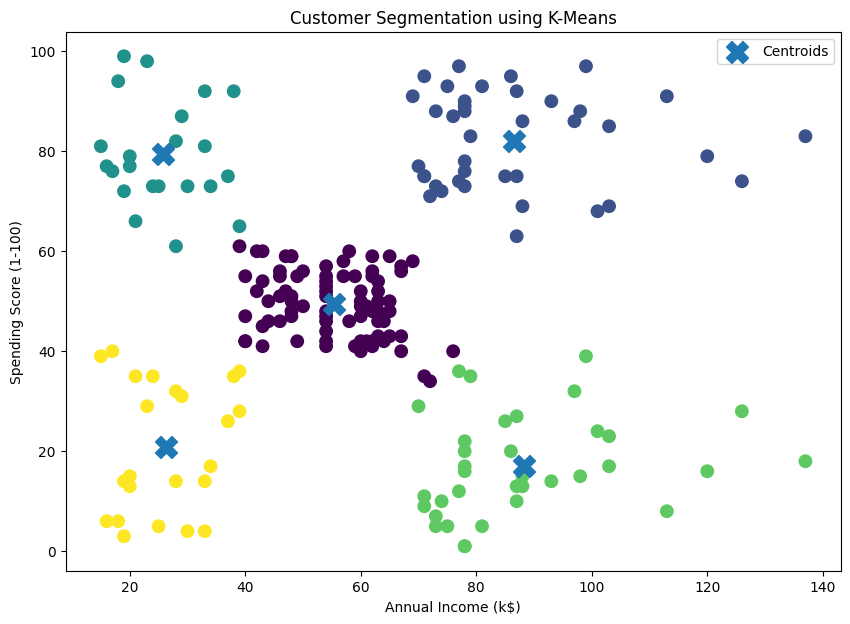

In [ ]:
plt.figure(figsize=(10,7))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=y_kmeans,
    s=80
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=250,
    label='Centroids'
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()

plt.show()

In [ ]:
centroid_df

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [ ]:
cluster_summary = df.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [ ]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,81
1,39
2,22
3,35
4,23


In [ ]:
silhouette_avg = silhouette_score(X, y_kmeans)

print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.553931997444648


In [ ]:
silhouette_scores = []

for k in range(2, 11):
    kmeans_temp = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    labels = kmeans_temp.fit_predict(X)

    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

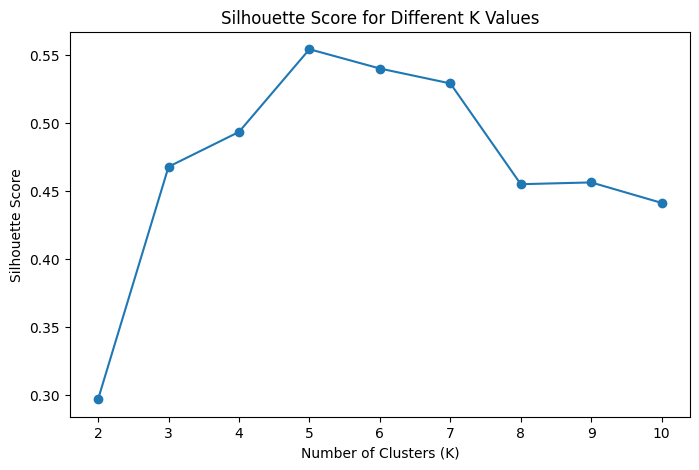

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score for Different K Values')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.show()

In [ ]:
centroid_df

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [ ]:
cluster_summary = df.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [ ]:
silhouette_avg = silhouette_score(X, y_kmeans)

print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.553931997444648


In [ ]:
cluster_names = {
    0: 'Average Customers',
    1: 'Target Customers',
    2: 'Potential Customers',
    3: 'Careful High-Income Customers',
    4: 'Low-Value Customers'
}

df['Customer Segment'] = df['Cluster'].map(cluster_names)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,1,Male,19,15,39,4,Low-Value Customers
1,2,Male,21,15,81,2,Potential Customers
2,3,Female,20,16,6,4,Low-Value Customers
3,4,Female,23,16,77,2,Potential Customers
4,5,Female,31,17,40,4,Low-Value Customers


## Customer Segments

Five customer groups were identified:

- Cluster 0: Average Customers
- Cluster 1: Target Customers
- Cluster 2: Potential Customers
- Cluster 3: Careful High-Income Customers
- Cluster 4: Low-Value Customers

## Model Evaluation

The Silhouette Score is 0.554, indicating reasonably good separation between the customer clusters.

In [ ]:
df['Customer Segment'].value_counts()

,count
Customer Segment,
Average Customers,81
Target Customers,39
Careful High-Income Customers,35
Low-Value Customers,23
Potential Customers,22


In [ ]:
final_summary = df.groupby('Customer Segment')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean().round(2)

final_summary

,Age,Annual Income (k$),Spending Score (1-100)
Customer Segment,,,
Average Customers,42.72,55.30,49.52
Careful High-Income Customers,41.11,88.20,17.11
Low-Value Customers,45.22,26.30,20.91
Potential Customers,25.27,25.73,79.36
Target Customers,32.69,86.54,82.13


In [ ]:
silhouette_scores = []

for k in range(2, 11):
    kmeans_temp = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    labels = kmeans_temp.fit_predict(X)

    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

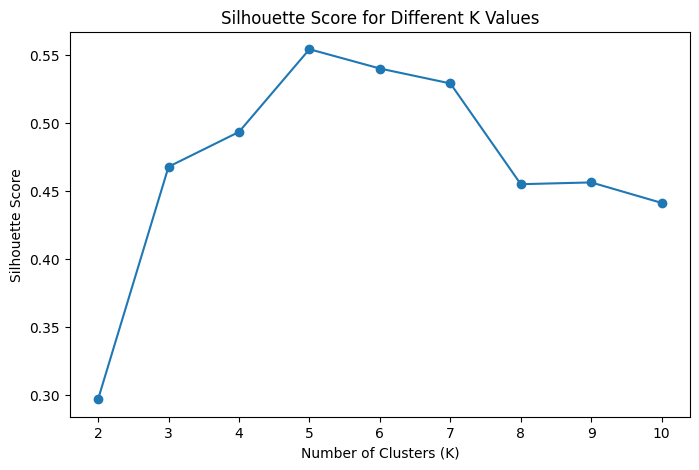

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score for Different K Values')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.show()

In [ ]:
df.to_csv(
    'Mall_Customers_with_Clusters.csv',
    index=False
)

## 3D Visualization

A 3D visualization was created using Age, Annual Income and Spending Score to provide an additional view of the customer clusters.

In [ ]:
X3 = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
kmeans_3d = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)

y_kmeans_3d = kmeans_3d.fit_predict(X3)

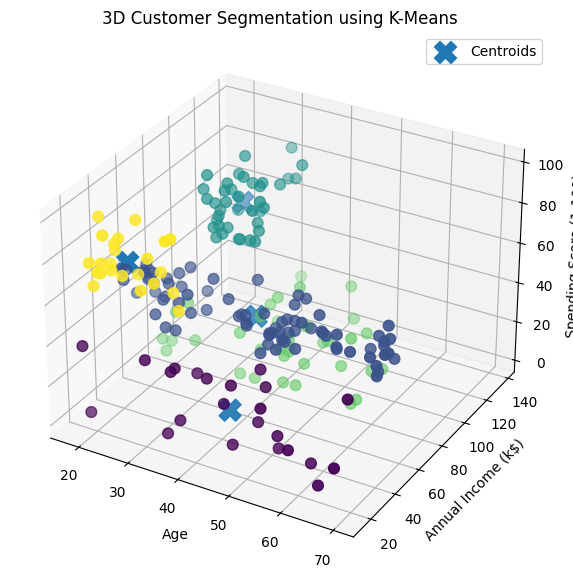

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X3['Age'],
    X3['Annual Income (k$)'],
    X3['Spending Score (1-100)'],
    c=y_kmeans_3d,
    s=60
)

# Plot centroids
centroids_3d = kmeans_3d.cluster_centers_

ax.scatter(
    centroids_3d[:, 0],
    centroids_3d[:, 1],
    centroids_3d[:, 2],
    marker='X',
    s=250,
    label='Centroids'
)

ax.set_title('3D Customer Segmentation using K-Means')
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')

ax.legend()

plt.show()

In [ ]:
from google.colab import files

files.download('Mall_Customers_with_Clusters.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

K-Means clustering successfully divided the customers into 5 meaningful groups.

The results can help businesses create targeted marketing strategies, personalized offers and loyalty programs for different customer segments.